In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# load data
Z = np.load('../data/processed/Z_256.npy')
errors = np.load('../data/processed/transformer_1_errors.npy')
X = np.load('../data/processed/X.npy')

In [3]:
# define anomaly threshold
top_percent = 2
threshold = np.percentile(errors, 100 - top_percent)
anomaly_indices = np.where(errors > threshold)[0]
Z_anomalies = Z[anomaly_indices]
np.save('../data/processed/anomaly_indices.npy', anomaly_indices)

print(f'Top {top_percent}% threshold: {threshold:.4f}')
print(f'Number of anomalies: {len(anomaly_indices)}')

# cluster anomalous latent vectors
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(Z_anomalies)
np.save('../data/processed/anomaly_clusters.npy', clusters)

Top 2% threshold: 0.1917
Number of anomalies: 192


In [4]:
# evaluate optimal number of clusters
wcss = []
silhouette_scores = []
K_range = range(2, 8)

print("\nEvaluating KMeans clustering quality:")
for k in K_range:
    kmeans_k = KMeans(n_clusters=k, random_state=42)
    labels_k = kmeans_k.fit_predict(Z_anomalies)
    wcss.append(kmeans_k.inertia_)
    sil_score = silhouette_score(Z_anomalies, labels_k)
    silhouette_scores.append(sil_score)
    print(f"k={k}, WCSS={kmeans_k.inertia_:.2f}, Silhouette Score={sil_score:.4f}")


Evaluating KMeans clustering quality:
k=2, WCSS=7800.69, Silhouette Score=0.2810
k=3, WCSS=7445.61, Silhouette Score=0.2334
k=4, WCSS=7144.81, Silhouette Score=0.2369
k=5, WCSS=6747.88, Silhouette Score=0.1480
k=6, WCSS=6561.08, Silhouette Score=0.1482
k=7, WCSS=6384.30, Silhouette Score=0.0823


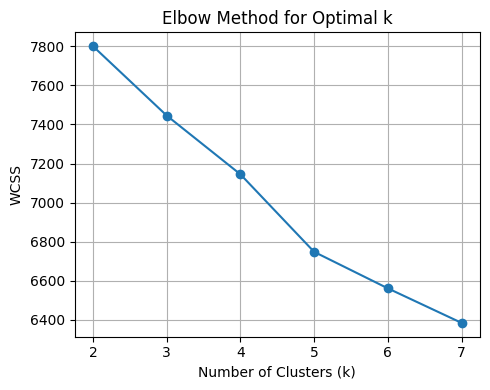

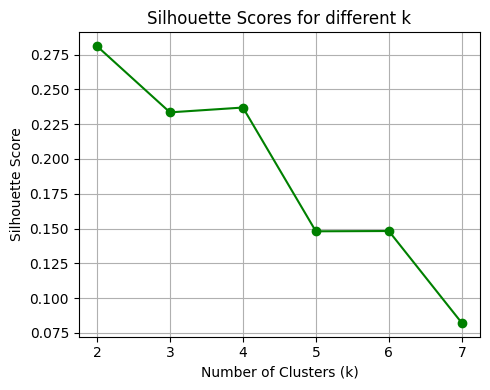

In [5]:
# plot elbow 
plt.figure(figsize=(5, 4))
plt.plot(K_range, wcss, 'o-', label='WCSS (Elbow)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.tight_layout()
plt.show()

# plot silhouette scores
plt.figure(figsize=(5, 4))
plt.plot(K_range, silhouette_scores, 'o-', color='green', label='Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for different k')
plt.grid(True)
plt.tight_layout()
plt.show()

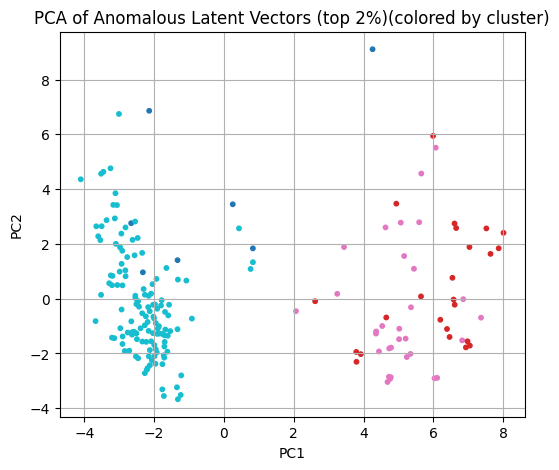

In [6]:
# PCA viz
Z_pca = PCA(n_components=2).fit_transform(Z_anomalies)
plt.figure(figsize=(6, 5))
plt.scatter(Z_pca[:, 0], Z_pca[:, 1], c=clusters, cmap='tab10', s=10)
plt.title(f"PCA of Anomalous Latent Vectors (top {top_percent}%)(colored by cluster)")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

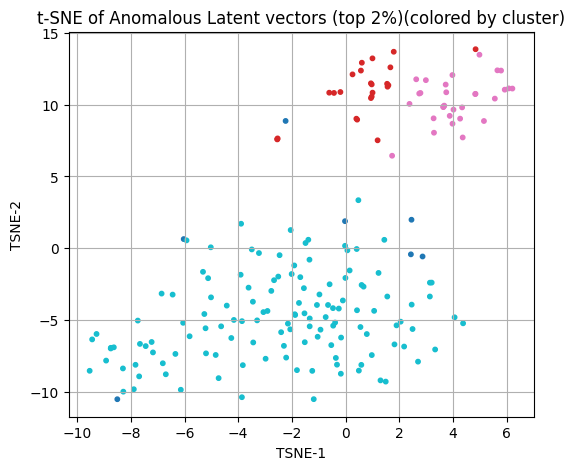

In [7]:
# t-SNE viz
Z_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(Z_anomalies)
plt.figure(figsize=(6, 5))
plt.scatter(Z_tsne[:, 0], Z_tsne[:, 1], c=clusters, cmap='tab10', s=10) 
plt.title(f't-SNE of Anomalous Latent vectors (top {top_percent}%)(colored by cluster)')
plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.grid(True)
plt.show()

## Understanding Cluster Characteristics

In [8]:
# convert to DataFrame for easier plotting
latent_df = pd.DataFrame(Z_anomalies)
latent_df['cluster'] = clusters

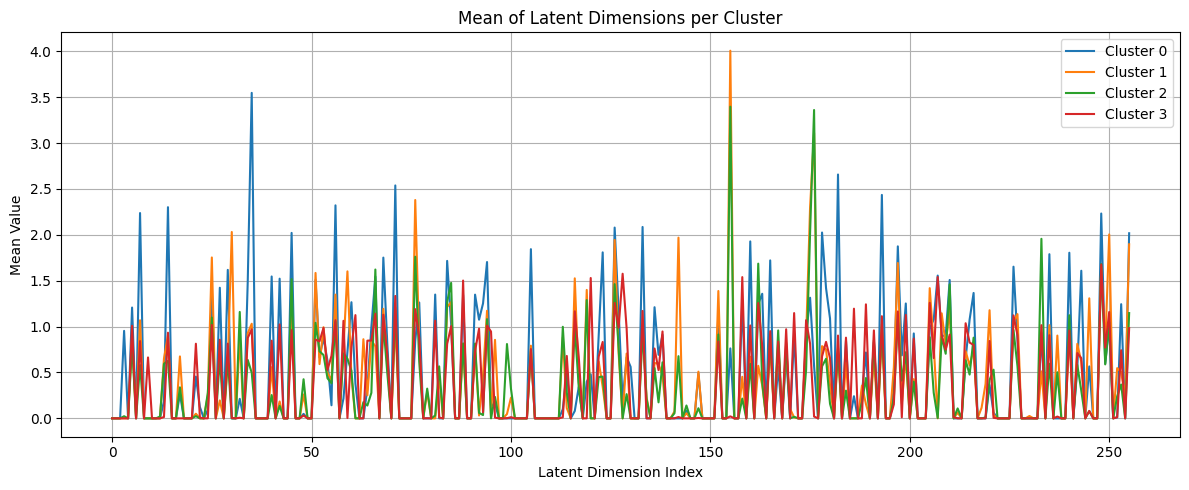

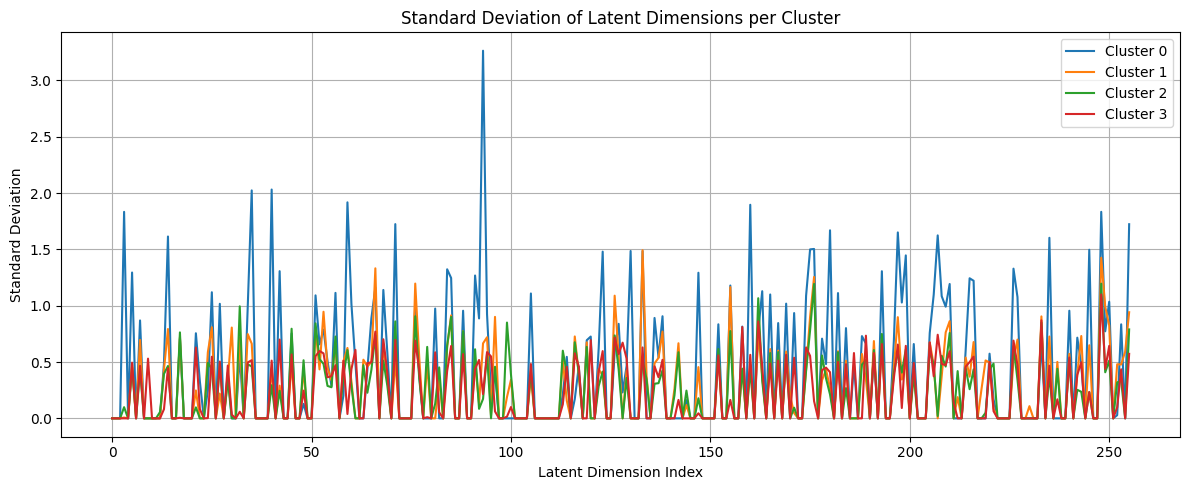

In [9]:
# compute mean and std for each cluster
cluster_stats = latent_df.groupby('cluster').agg(['mean', 'std'])

# plot mean of each latent dimension per cluster
means = cluster_stats.xs('mean', axis=1, level=1)
plt.figure(figsize=(12, 5))
for c in means.index:
    plt.plot(means.loc[c].values, label=f'Cluster {c}')
plt.title("Mean of Latent Dimensions per Cluster")
plt.xlabel("Latent Dimension Index")
plt.ylabel("Mean Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# plot std of each latent dimension per cluster
stds = cluster_stats.xs('std', axis=1, level=1)
plt.figure(figsize=(12, 5))
for c in stds.index:
    plt.plot(stds.loc[c].values, label=f"Cluster {c}")
plt.title("Standard Deviation of Latent Dimensions per Cluster")
plt.xlabel("Latent Dimension Index")
plt.ylabel("Standard Deviation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
